### kNN

In [1]:
import pandas as pd

In [2]:
# 데이터 불러오기
df_train = pd.read_csv('../Data/basketball_train.csv')
df_test = pd.read_csv('../Data/basketball_test.csv')

In [3]:
df_train.head()

,Player,Pos,3P,TRB,BLK
0,Pau Gasol,C,0.9,7.8,1.1
1,Nicolas Batum,SG,1.8,6.2,0.4
2,Allen Crabbe,SG,1.7,2.9,0.3
3,Manu Ginobili,SG,1.3,2.3,0.2
4,Danny Green,SG,1.7,3.3,0.8


In [4]:
df_test.head()

,Player,Pos,3P,TRB,BLK
0,Avery Bradley,SG,2.0,6.1,0.2
1,Zach LaVine,SG,2.6,3.4,0.2
2,Troy Daniels,SG,2.1,1.5,0.1
3,Will Barton,SG,1.5,4.3,0.5
4,Willie Cauley-Stein,C,0.0,4.5,0.6


In [5]:
# 전체 갯수 확인
print(df_train.shape)
print(df_test.shape)

(80, 5)
(20, 5)


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  80 non-null     object 
 1   Pos     80 non-null     object 
 2   3P      80 non-null     float64
 3   TRB     80 non-null     float64
 4   BLK     80 non-null     float64
dtypes: float64(3), object(2)
memory usage: 3.3+ KB


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  20 non-null     object 
 1   Pos     20 non-null     object 
 2   3P      20 non-null     float64
 3   TRB     20 non-null     float64
 4   BLK     20 non-null     float64
dtypes: float64(3), object(2)
memory usage: 932.0+ bytes


### 최적의 K 찾기와 교차검증 (Cross Validation)

In [8]:
print("hello")

hello


In [9]:
from sklearn.neighbors import KNeighborsClassifier

In [10]:
from sklearn.model_selection import cross_val_score

In [11]:
# 최적의 k를 찾기 위해 교차 검증을 수행할 k의 범위를 3부터 학습데이터의 절반까지 지정
max_k_range = df_train.shape[0] // 2 # // 슬래시 두개 -> 몫만 출력한다

In [12]:
# 최적의 k를 찾기 위한 범위 확인
k_list = [i for i in range(3, max_k_range, 2)]
k_list

[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]

In [13]:
train_data = df_train[['3P', 'BLK', 'TRB']]
train_target = df_train['Pos']

In [14]:
# 교차 검증(10 fold)을 각 k를 대상으로 수행해 검증결과를 저장
cross_validation_scores = []

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn,
        train_data,
        train_target,
        cv=10, # cross validation : 9개는 학습용, 1개는 검증용으로 사용
        scoring='accuracy'
    )
    print(k, ":", scores)
    cross_validation_scores.append(scores.mean()) # 검증결과의 평균값을 저장

3 : [0.875 0.875 0.875 0.875 0.875 0.875 0.75  1.    1.    0.75 ]
5 : [0.875 0.75  0.875 0.875 1.    1.    0.75  1.    1.    0.875]
7 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
9 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
11 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
13 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
15 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
17 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
19 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
21 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
23 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
25 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
27 : [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
29 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
31 : [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]

In [15]:
print(cross_validation_scores)

[np.float64(0.875), np.float64(0.9), np.float64(0.875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.8875), np.float64(0.875), np.float64(0.875), np.float64(0.8625), np.float64(0.85), np.float64(0.8375), np.float64(0.8375)]


In [16]:
# k의 정확도 시각화
import matplotlib.pyplot as plt

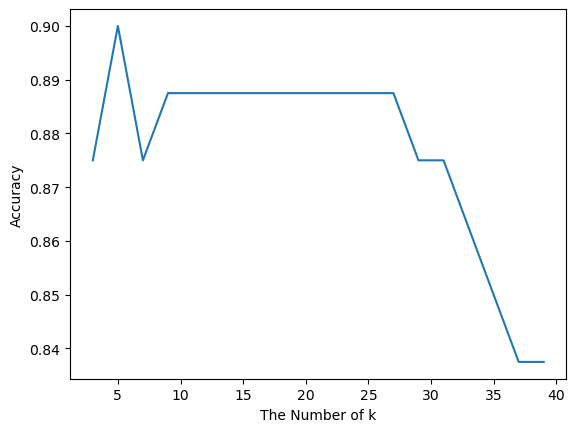

In [17]:
plt.plot(
    k_list,
    cross_validation_scores
)

plt.xlabel('The Number of k')
plt.ylabel('Accuracy')

plt.show()

In [18]:
# 가장 예측률이 높은 k를 선정
k_list[cross_validation_scores.index(max(cross_validation_scores))]

5

---
#### 2개의 특징으로 예측하기 ( 3점슛, 블로킹 )

In [19]:
# Model
knn = KNeighborsClassifier(n_neighbors=5)

In [20]:
# Feature
train_data = df_train[['3P', 'BLK']]

In [21]:
knn.fit(train_data, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
test_data = df_test[['3P', 'BLK']]
test_target = df_test['Pos']

In [23]:
print("Train :", knn.score(train_data, train_target))
print("Test :", knn.score(test_data, test_target))

Train : 0.9625
Test : 0.95


----
3개의 특징으로 예측하기 (3점슛, 리바운드, 블로킹)

In [24]:
train_data_2 = df_train[['3P', 'TRB', 'BLK']]
train_target_2 = df_train['Pos']
test_data_2 = df_test[['3P', 'TRB', 'BLK']]
test_target_2 = df_test['Pos']

In [25]:
knn.fit(train_data_2, train_target_2)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [26]:
train_data_2

,3P,TRB,BLK
0,0.9,7.8,1.1
1,1.8,6.2,0.4
2,1.7,2.9,0.3
3,1.3,2.3,0.2
4,1.7,3.3,0.8
...,...,...,...
75,0.0,10.4,0.7
76,0.0,4.2,0.8
77,1.9,4.3,0.3
78,0.0,5.1,1.3


In [27]:
test_data_2

,3P,TRB,BLK
0,2.0,6.1,0.2
1,2.6,3.4,0.2
2,2.1,1.5,0.1
3,1.5,4.3,0.5
4,0.0,4.5,0.6
5,1.4,6.3,1.3
6,0.0,3.8,0.7
7,1.5,4.0,0.1
8,0.9,4.1,0.7
9,0.0,3.2,1.0


In [28]:
print("Train :", knn.score(train_data_2, train_target_2))
print("Test :", knn.score(test_data_2, test_target_2))

Train : 0.925
Test : 0.9


In [29]:
# 어떤 선수의 점수가 아래와 같은 경우, 포지션 추천하기
# 3P = 3.4, BLK = 0,5, TRB = 3.7
knn.predict([[3.4, 3.7, 0.5]])[0]

c:\Users\tuxca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'SG'

In [30]:
# 점수입력
data = {
    '3P' : [3.4],
    'TBR' : [3.7],
    'BLK' : [0.5]
}

df = pd.DataFrame(data)
df

,3P,TBR,BLK
0,3.4,3.7,0.5


In [36]:
# 예측
# knn.predict(df)
pred = knn.predict([[3.4, 3.7, 0.5]])
print(f"추천하는 포지션은 {pred[0]} 입니다.")

추천하는 포지션은 SG 입니다.


c:\Users\tuxca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


### AI 저장하기

In [32]:
import joblib

In [33]:
joblib.dump(knn, '../Data/knn_basketball.h5')

['../Data/knn_basketball.h5']